In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score
import seaborn as sns

In [33]:
DS=pd.read_csv('online_shoppers_intention.csv')
featur=DS.iloc[:,:-1].values
target=DS.iloc[:,-1].values

In [34]:
print(DS.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [35]:
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[10,15,16])],remainder='passthrough')
featur=ct.fit_transform(featur)
featur=np.array(featur)
le=LabelEncoder()
target=le.fit_transform(target)

In [36]:
featur_train,featur_test,target_train,target_test= train_test_split(featur,target,test_size=0.2,random_state=42)

In [37]:
sc=StandardScaler()
featur_train=sc.fit_transform(featur_train)
featur_test=sc.transform(featur_test)

In [38]:
classifier=KNeighborsClassifier(n_neighbors=5,metric='minkowski',p=2)
classifier.fit(featur_train,target_train)

KNeighborsClassifier()

In [39]:
new_data = ct.transform([[0, 0.0, 0, 0.0, 1, 5.0, 0.2, 0.2, 0.0, 0.0, 'Feb', 1, 1, 3, 1, 'New_Visitor', False]])
print(classifier.predict(sc.transform(new_data)))

[0]


In [40]:
target_pred=classifier.predict(featur_test)
print(np.concatenate((target_pred.reshape(len(target_pred),1),target_test.reshape(len(target_test),1)),1))

[[0 0]
 [0 1]
 [0 0]
 ...
 [0 0]
 [1 1]
 [0 0]]


In [41]:
cm=confusion_matrix(target_test,target_pred)
print(cm)
accuracy_score(target_test,target_pred)

[[1999   56]
 [ 273  138]]


0.8665855636658556

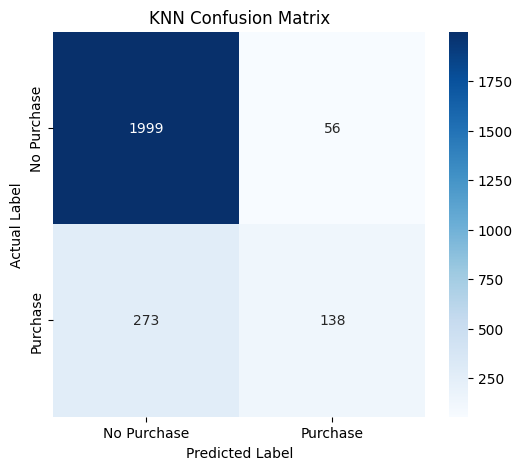

In [42]:
cm = confusion_matrix(target_test, target_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.title('KNN Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

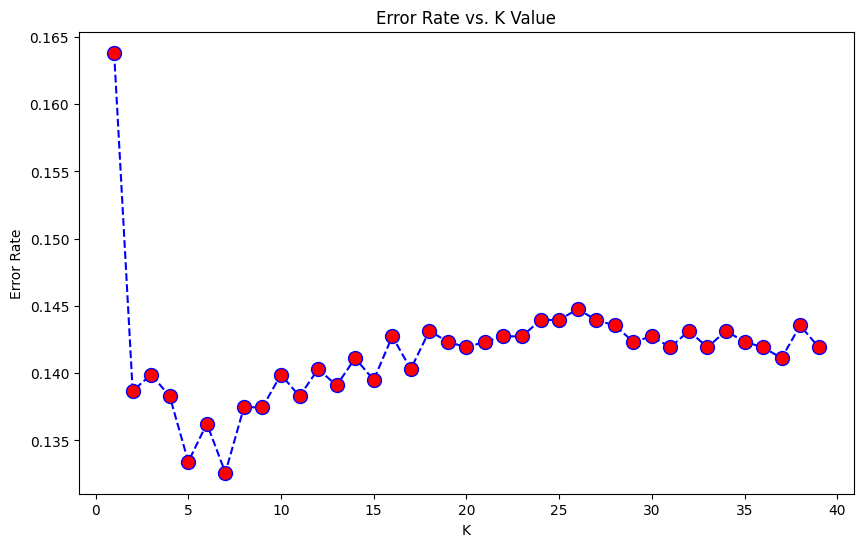

In [43]:
error_rate = []
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(featur_train, target_train)
    pred_i = knn.predict(featur_test)
    error_rate.append(np.mean(pred_i != target_test))

# رسم الخطأ مقابل قيمة K
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()